# Plotando diversos gráficos na mesma grade

Nós podemos fazer o plot de diferentes gráficos na mesma saída de uma célula utilizando o matplotlib e seaborn. Para isso, precisaremos utilizar o comando `plt.subplots`, que retorna um série de linhas e colunas que poderemos plotar nossos gráficos

In [1]:
from urllib.request import urlretrieve
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import numpy as np
from PIL import Image

sns.set_style('darkgrid')
matplotlib.rcParams['figure.figsize'] = (9, 5)

(<Figure size 900x500 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

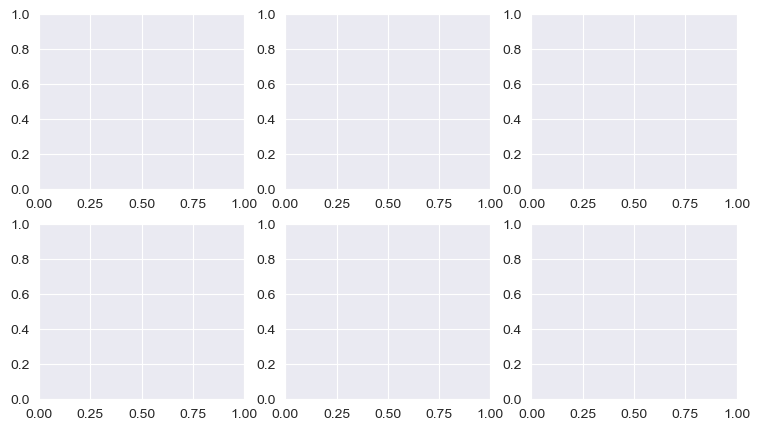

In [2]:
plt.subplots(2, 3) #Permitirá criar uma grade de subplots de 2 linhas e 3 colunas

Para manipular o espaçamento entre os gráficos podemos utilizar o comando `plt.tight_layout`

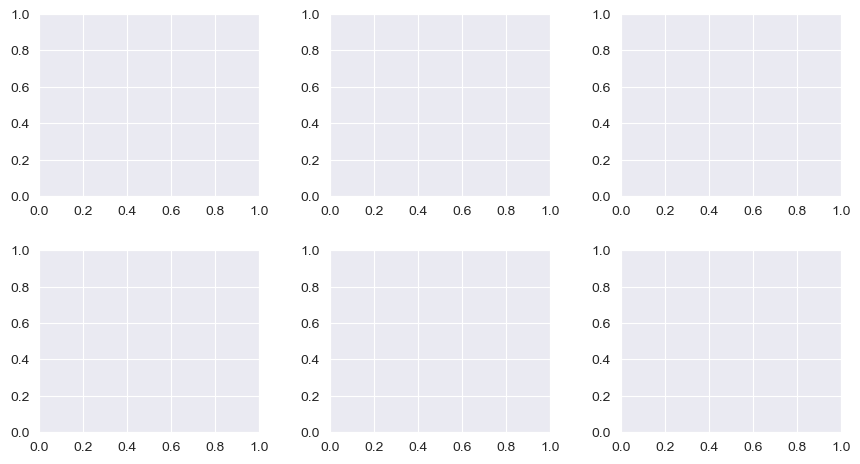

In [3]:
plt.subplots(2, 3)
plt.tight_layout(pad=2.0) #Ajusta o espaçamento entre os subplots para evitar sobreposição

Podemos ver na saída da célula que o `plt.subplots` retorna duas coisas: uma figura (figura contendo os gráficos montados) e um array de linhas (contém a ordem dos subplot armazenados em um vetor do tipo numpy)

In [4]:
years = range(2000, 2006)
apples = [0.35, 0.6, 0.9, 0.8, 0.65, 0.8]
oranges = [0.4, 0.8, 0.9, 0.7, 0.6, 0.8]

In [20]:
flowers_df = sns.load_dataset('iris')
setosa_df = flowers_df[flowers_df['species'] == 'setosa']
virginica_df = flowers_df[flowers_df['species'] == 'virginica']
versicolor_df = flowers_df[flowers_df['species'] == 'versicolor']

In [22]:
tips_df = sns.load_dataset("tips")

In [25]:
flights_df = sns.load_dataset('flights').pivot(index='month', columns='year', values='passengers')

In [28]:
img = Image.open('chart.jpeg')

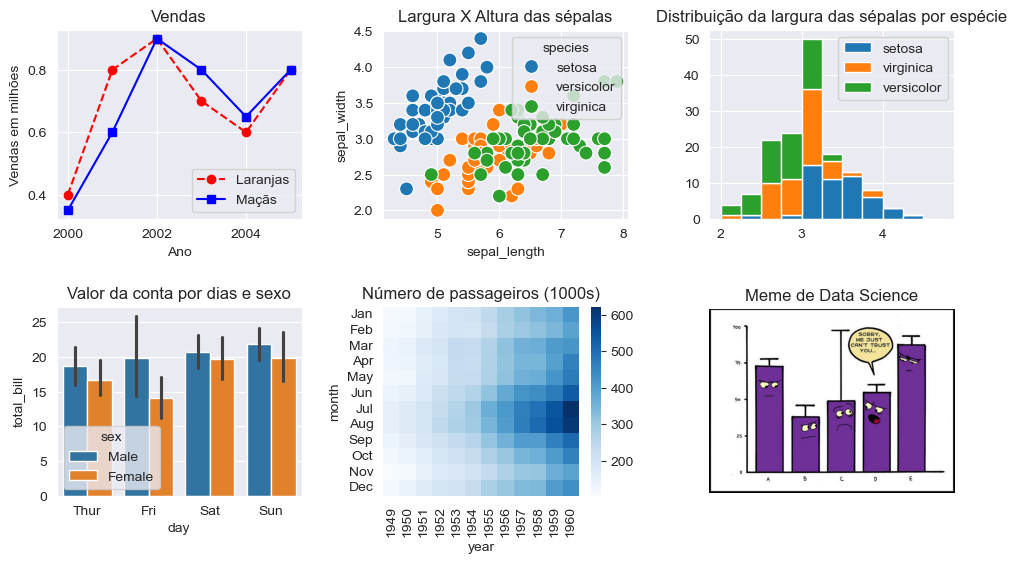

In [33]:
from inspect import stack


fig, axes = plt.subplots(2, 3, figsize=(10, 6))

#Representa o gráfico de linhas de laranjas localizado na primeira linha e primeira coluna
axes[0, 0].plot(years, oranges, 'o--r'); 
axes[0, 0].set_title('Vendas')
axes[0, 0].set_xlabel('Ano')
axes[0, 0].set_ylabel('Vendas em milhões')
axes[0, 0].plot(years, apples, 's-b')
axes[0, 0].legend(['Laranjas', 'Maçãs'])

axes[0, 1].set_title('Largura X Altura das sépalas')
sns.scatterplot(x=flowers_df['sepal_length'],
                y=flowers_df['sepal_width'],
                hue=flowers_df['species'],
                s=100,
                ax=axes[0, 1],) #Aqui, especificamos para qual eixo o gráfico deve ser desenhado e isso também ja diz onde as alterações devem ser aplicadas


#Representa o histograma da largura das sépalas localizado na primeira linha e terceira coluna
axes[0, 2].set_title('Distribuição da largura das sépalas por espécie')
axes[0, 2].hist([setosa_df['sepal_width'],
                 virginica_df['sepal_width'],
                 versicolor_df['sepal_width']],
                 bins=np.arange(2, 5, 0.25),
                 stacked=True,)
axes[0, 2].legend(['setosa', 'virginica', 'versicolor'])

#Plot de barras na segunda linha e primeira coluna
axes[1, 0].set_title('Valor da conta por dias e sexo')
sns.barplot(x='day', y='total_bill', hue='sex', data=tips_df, ax=axes[1, 0])

#Plotando Heatmap na segunda linha e segunda coluna
axes[1, 1].set_title('Número de passageiros (1000s)')
sns.heatmap(flights_df, fmt='d', annot=False, cmap='Blues', ax=axes[1, 1]);

#Plotando uma imagem na segunda linha e terceira coluna
axes[1, 2].set_title('Meme de Data Science')
axes[1, 2].imshow(img)
axes[1, 2].grid(False)
axes[1, 2].axis('off')  # Remove os eixos para uma melhor visualização da imagem
axes[1, 2].set_xticks([])  # Remove os ticks do eixo x
axes[1, 2].set_yticks([])  # Remove os ticks do eixo y

plt.tight_layout(pad=2)

Aqui podemos ver alguns dos princiapais gráficos que podem ser plotados com MatplotLib e Seaborn, porém no dia-a-dia não precisremos decorar a exata sintaxe de como plotar esses gráficos, então por isso, teremos que verificar as documentações dessas bibliotecas e pegar as informações para plotar o que queremos. Para isso poderemos acessar as seguintes documentações:

- Matplotlib: https://matplotlib.org/stable/
- Seaborn: https://seaborn.pydata.org/examples/index.html